# Proyek Akhir PKK - Kelompok 14
# MODUL 1: DATA & ENVIRONMENT SETUP
Fokus Eksekusi: Membaca struktur teksnya, dan mengonversinya menjadi matriks 2D menggunakan NumPy. Memastikan koordinat titik awal (start) dan target (goal) terpetakan dengan benar dan tidak jatuh di atas area rintangan.

[INFO] Dataset 'D:\Games\Code\Semester 6\PKK\Mini_Project\dao-map\arena.map' berhasil dimuat. Ukuran grid: 49 baris x 49 kolom.


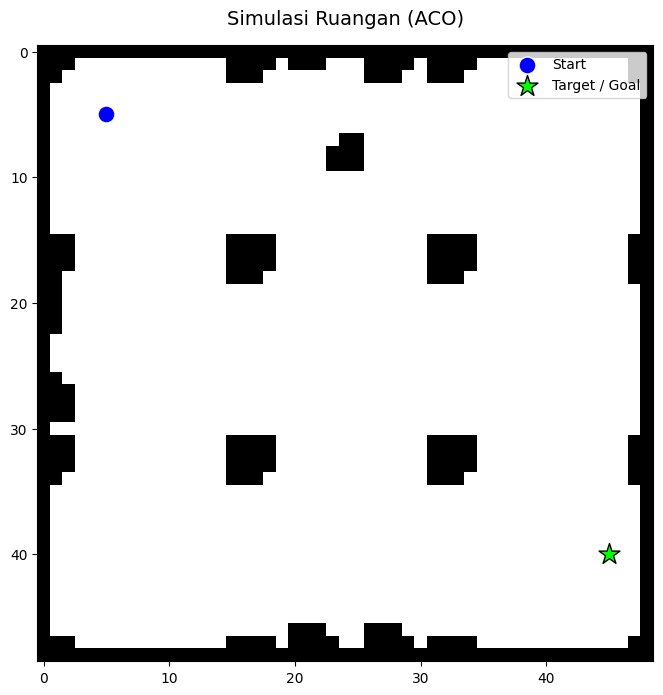

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

class EnvironmentManager:
    """
    Kelas untuk menangani ekstraksi dataset .map dan visualisasi tata letak
    untuk simulasi Ant Colony Optimization (ACO).
    """
    
    @staticmethod
    def load_moving_ai_map(filepath):
        """Membaca file .map dan mengonversinya menjadi matriks NumPy."""
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"File dataset tidak ditemukan di path: {filepath}")
            
        with open(filepath, 'r') as file:
            lines = file.readlines()
            
        # Mengekstrak metadata dari header
        height = int(lines[1].strip().split(' ')[1])
        width = int(lines[2].strip().split(' ')[1])
        print(f"[INFO] Dataset '{filepath}' berhasil dimuat. Ukuran grid: {height} baris x {width} kolom.")
        
        grid = []
        # Peta selalu dimulai dari baris ke-5
        for line in lines[4:]:
            row = []
            for char in line.strip():
                # 0 merepresentasikan area yang bisa dilalui karakter
                if char in ['.', 'G', 'S']:  
                    row.append(0)
                # 1 merepresentasikan rintangan/dinding yang harus dihindari semut
                else:
                    row.append(1)
            grid.append(row)
            
        return np.array(grid)

    @staticmethod
    def visualize_grid(grid, start_node, goal_node, title="Simulasi Ruangan (ACO)"):
        """Menampilkan plot visual dari environment matriks beserta titik awal dan tujuan."""
        plt.figure(figsize=(8, 8))
        
        # Peta divisualisasikan: 0 (jalan) berwarna putih, 1 (rintangan) berwarna hitam
        plt.imshow(grid, cmap='Greys', origin='upper')
        
        # Menandai posisi Start (Biru) dan Goal (Hijau)
        # Ingat: Matplotlib (x,y) setara dengan NumPy (kolom, baris)
        plt.scatter(start_node[1], start_node[0], c='blue', marker='o', s=150, edgecolors='white', label='Start')
        plt.scatter(goal_node[1], goal_node[0], c='lime', marker='*', s=250, edgecolors='black', label='Target / Goal')
        
        plt.title(title, fontsize=14, pad=15)
        plt.legend(loc='upper right')
        plt.grid(False) # Dimatikan agar tidak mengganggu visual blok matriks
        plt.show()

# ==========================================
# BLOK EKSEKUSI (Bisa dijalankan di cell terpisah)
# ==========================================

# 1. Definisikan path file dataset Anda
# Pastikan file .map dari Moving AI berada di folder yang sama dengan file .ipynb ini
DATASET_FILE = r'D:\Games\Code\Semester 6\PKK\Mini_Project\dao-map\arena.map' 

try:
    # 2. Eksekusi ekstraksi matriks
    env_manager = EnvironmentManager()
    env_matrix = env_manager.load_moving_ai_map(DATASET_FILE)
    
    # 3. Definisikan Koordinat Mulai dan Selesai
    # Format koordinat: (Baris/Y, Kolom/X)
    # PENTING: Pastikan koordinat yang dipilih bernilai 0 di dalam env_matrix
    start_pos = (5, 5)   
    target_pos = (40, 45) 
    
    # Validasi singkat agar semut tidak diletakkan di dalam tembok
    if env_matrix[start_pos[0], start_pos[1]] == 1:
        print("[PERINGATAN] Titik Start berada di dalam rintangan!")
    if env_matrix[target_pos[0], target_pos[1]] == 1:
        print("[PERINGATAN] Titik Target berada di dalam rintangan!")
        
    # 4. Tampilkan Hasil
    env_manager.visualize_grid(env_matrix, start_pos, target_pos)

except Exception as e:
    print(f"Terjadi kesalahan: {e}")